In [127]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import glob
from ase.io import read, write
from ase.build import make_supercell
import numpy as np

# FIGURA 1

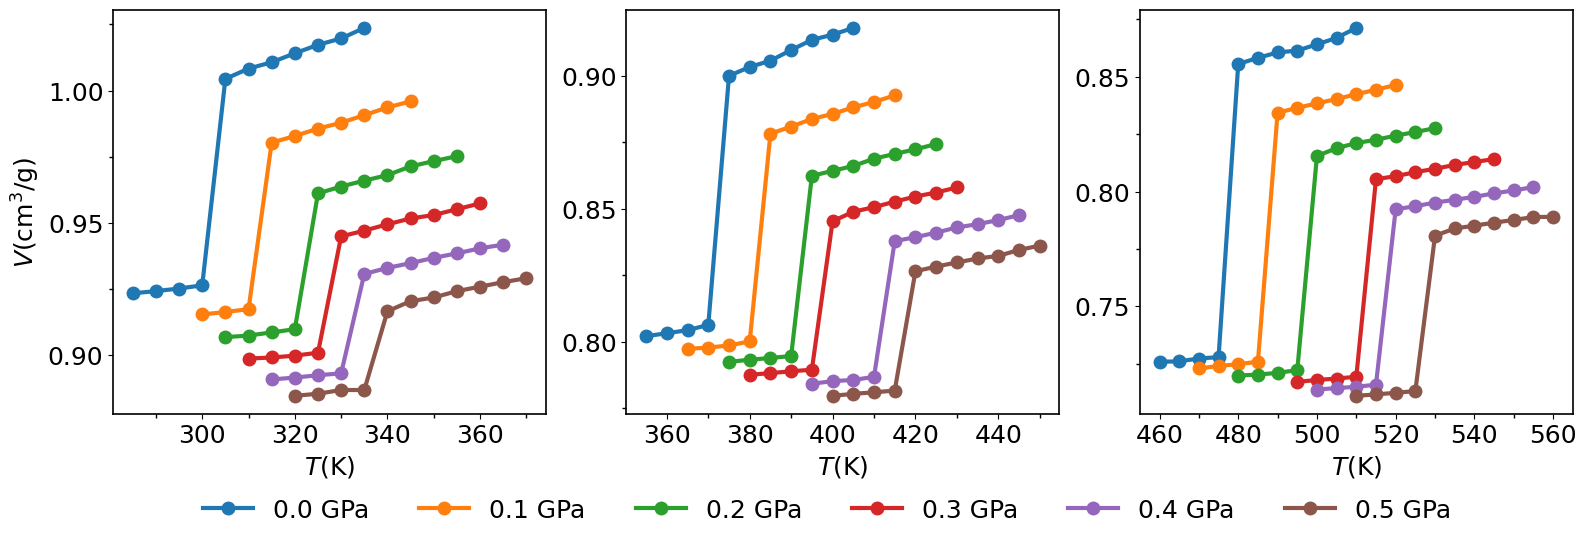

In [250]:

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']
materials = ['NPG', 'PG', 'PE']
pressures = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

all_handles, all_labels = [], []

for idx, (ax, material) in enumerate(zip(axes, materials)):
    files = sorted(glob.glob(f"/home/aressanuy/Desktop/doc/paper-npgpgpe/f_volum/P*_{material}.dat"))

    if not files:
        ax.text(0.5, 0.5, f'No hi ha dades\nper {material}',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        continue

    for i, fpath in enumerate(files):
        label = f'{pressures[i]} GPa'
        try:
            data = np.loadtxt(fpath, comments='#')
            if data.ndim == 1:
                data = data[np.newaxis, :]
            T = data[:, 0]
            if material == 'PE':
                V = data[:, 1] * 0.0043
            if material == 'NPG':
                V = data[:, 1]
            if material == 'PG':
                V = data[:, 1] * 0.0098

            line, = ax.plot(T, V, 'o-', color=colors[i % len(colors)],
                            label=label, linewidth=3, markersize=9)
            if idx == 0:
                all_handles.append(line)
                all_labels.append(label)
        except Exception as e:
            print(f"  Error llegint {fpath}: {e}")

    ax.set_xlabel(r'$T\mathrm{(K)}$', fontsize=18)
    if idx == 0:
        ax.set_ylabel(r'$V\mathrm{(cm^3/g)}$', fontsize=18)

    ax.tick_params(axis='both', labelsize=18)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=3, width=1)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

fig.legend(all_handles, all_labels, loc='lower center', ncol=len(pressures),
           fontsize=18, bbox_to_anchor=(0.52, -0.10),frameon=False)
plt.tight_layout()
plt.savefig('/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/fig1.png', dpi=150, bbox_inches='tight')
plt.show()


# FIGURA 3

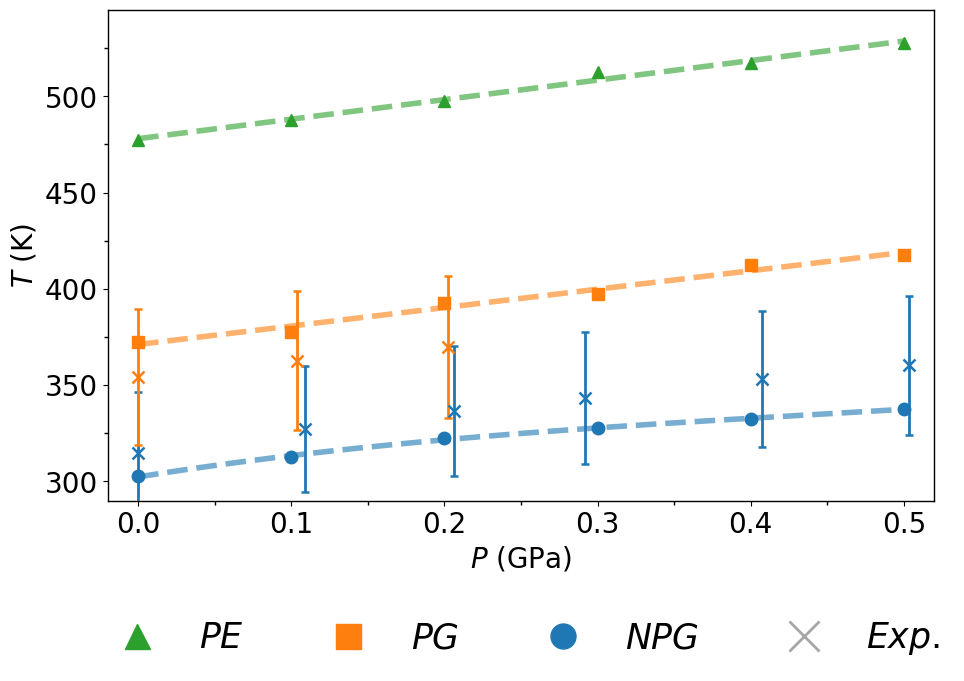

In [311]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

P = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5])

data_T = {
    'NPG': [302.5, 312.5, 322.5, 327.5, 332.5, 337.5],
    'PG':  [372.5, 377.5, 392.5, 397.5, 412.5, 417.5],
    'PE':  [477.5, 487.5, 497.5, 512.5, 517.5, 527.5],
}

# ── Punts experimentals ───────────────────────────────────────────────────────
_npg_data = np.loadtxt('/home/aressanuy/Desktop/doc/paper-npgpgpe/fitxers/PT_NPG_exp.dat', comments='#')
_npg_P, _npg_T = _npg_data[:, 0], _npg_data[:, 1]

_pg_P_MPa = [0, 1039, 2026]
_pg_T = np.array([354.24, 362.71, 369.74])

exp_T = {
    'NPG': {'P': _npg_P,                      'T': _npg_T, 'yerr': 0.1 * _npg_T},
    'PG':  {'P': np.array(_pg_P_MPa) / 10000, 'T': _pg_T,  'yerr': 0.1 * _pg_T},
    'PE':  None,
}

colors  = {'NPG': 'tab:blue', 'PG': 'tab:orange', 'PE': 'tab:green'}
markers = {'NPG': 'o',        'PG': 's',           'PE': '^'}
degrees = {'NPG': 3,          'PG': 1,             'PE': 1}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

P_fit = np.linspace(0, 0.5, 300)

# Punts de simulació: sense capsize, ecolor més discret
for mat, T_list in data_T.items():
    T = np.array(T_list)
    ax.errorbar(P, T, yerr=0,
                fmt=markers[mat], color=colors[mat],
                ecolor=colors[mat], capsize=0,          # sense capsize
                elinewidth=1.2, linewidth=0,
                markersize=9, label=mat, zorder=5)
    coefs = np.polyfit(P, T, degrees[mat])
    ax.plot(P_fit, np.poly1d(coefs)(P_fit),
            '--', color=colors[mat], linewidth=4, alpha=0.6, label='_nolegend_')

# Punts experimentals: 'x' + barres en alpha per no saturar
for mat, edata in exp_T.items():
    if edata is None:
        continue
    P_e = np.array(edata['P'])
    T_e = np.array(edata['T'])
    ye  = np.array(edata['yerr'])
    c   = colors[mat]

    ax.errorbar(P_e, T_e, yerr=ye,
                fmt='x', color=c,
                ecolor=c, capsize=3,
                elinewidth=2, alpha=1,             # alpha baix
                markersize=9, markeredgewidth=1.8,
                zorder=4, label='_nolegend_')

# ── Llegenda ──────────────────────────────────────────────────────────────────
sim_handles = [
    Line2D([0], [0], marker=markers[m], color=colors[m],
           linestyle='None', markersize=6)
    for m in ['PE', 'PG', 'NPG']
]
fit_handle = Line2D([0], [0], linestyle='--', color='gray', linewidth=1.5)
exp_handle = Line2D([0], [0], marker='x', color='gray', linestyle='None',
                    markersize=7, markeredgewidth=2, alpha=0.7)

ax.legend(
    handles=sim_handles + [exp_handle],
    labels=[r'$PE$', r'$PG$', r'$NPG$', r'$Exp.$'],
    fontsize=25, ncol=5,
    markerscale=3,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    frameon=False,                        # ← canvia a True
    edgecolor='gray',                    # ← color del marc (opcional)
    framealpha=0.6,                      # ← fons opac (opcional)
)

# ── Eixos i format ────────────────────────────────────────────────────────────
ax.set_xlabel(r'$P$ (GPa)', fontsize=20)
ax.set_ylabel(r'$T$ (K)',   fontsize=20)
ax.set_ylim(290, 545)
ax.set_xlim(-0.02, 0.52)
ax.tick_params(axis='both', labelsize=20)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.tick_params(which='minor', length=3, width=1)
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig('/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/fig3.png', dpi=150, bbox_inches='tight')
plt.show()

# FIGURA 4

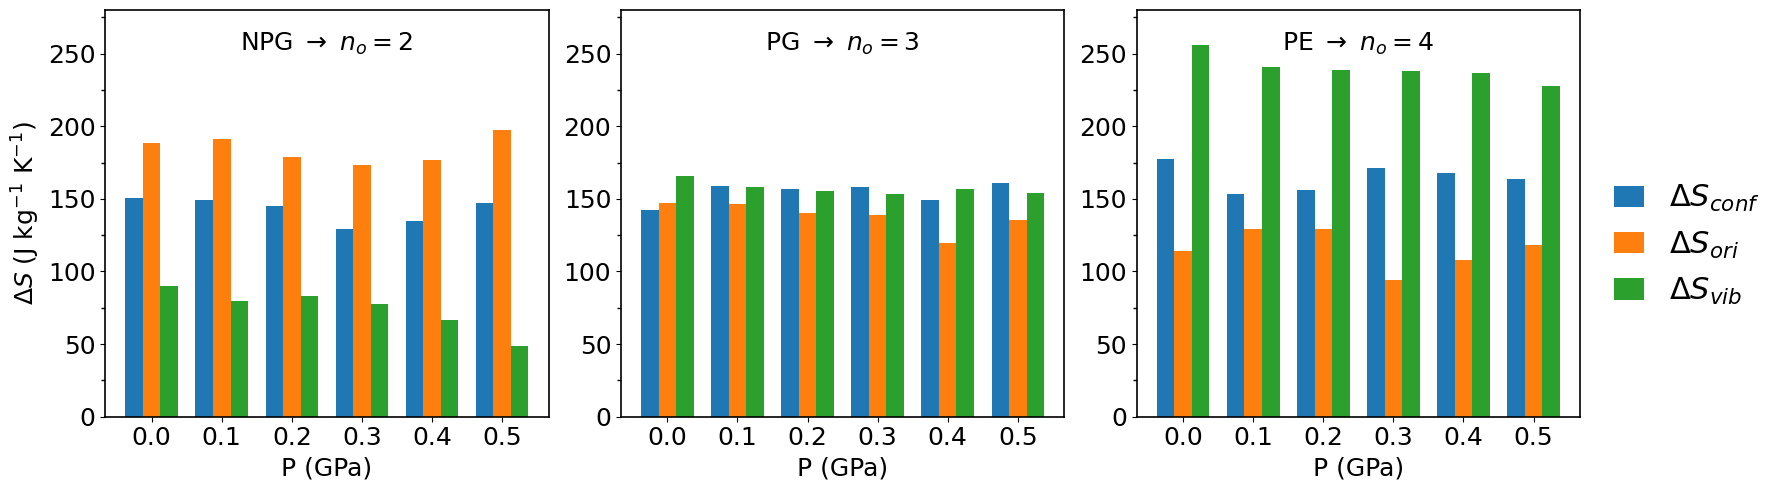

In [297]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pressures_labels = ['0.0', '0.1', '0.2', '0.3', '0.4', '0.5']
x = np.arange(6)
width = 0.25

data = {
    'NPG': {
        'ori':  [188.37, 191.39, 179.09, 173.00, 176.70, 197.71],
        'conf': [150.45, 149.34, 144.81, 129.00, 134.76, 146.92],
        'vib':  [ 90.00,  80.00,  83.36,  77.82,  66.36,  48.77],
    },
    'PG': {
        'ori':  [147.26, 146.45, 140.38, 139.00, 119.90, 135.32],
        'conf': [142.25, 159.08, 156.75, 158.43, 149.12, 160.99],
        'vib':  [165.96, 157.92, 155.66, 153.67, 156.67, 153.75],
    },
    'PE': {
        'ori':  [113.91, 129.13, 129.27, 94.27, 107.88, 117.99],
        'conf': [177.26, 153.21, 156.04, 171.46, 167.45, 163.80],
        'vib':  [255.94, 240.93, 238.59, 238.15, 236.62, 227.64],
    },
}

hbonds = {'NPG': 2, 'PG': 3, 'PE': 4}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

legend_handles = None

for idx, (ax, (material, vals)) in enumerate(zip(axes, data.items())):
    ori  = vals['ori']
    conf = vals['conf']
    vib  = vals['vib']

    b1 = ax.bar(x - width, conf, width, color='#1f77b4', label=r'$\Delta S_{conf}$')
    b2 = ax.bar(x,         ori,  width, color='#ff7f0e', label=r'$\Delta S_{ori}$')
    b3 = ax.bar(x + width, vib,  width, color='#2ca02c', label=r'$\Delta S_{vib}$')

    ax.set_xlabel('P (GPa)', fontsize=18)
    if idx == 0:
        ax.set_ylabel(r'$\Delta S$ (J kg$^{-1}$ K$^{-1}$)', fontsize=18)
        legend_handles = [b1, b2, b3]

    ax.set_xticks(x)
    ax.set_xticklabels(pressures_labels, fontsize=18)
    ax.set_ylim(0, 280)

    ax.tick_params(axis='both', labelsize=18)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=3, width=1)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.text(0.5, 0.95,
            f'$\\mathrm{{{material}}}$ $\\rightarrow$ $n_o = {hbonds[material]}$',
            transform=ax.transAxes, fontsize=18,
            ha='center', va='top')

fig.legend(handles=legend_handles,
           labels=[r'$\Delta S_{conf}$', r'$\Delta S_{ori}$', r'$\Delta S_{vib}$'],
           loc='center right', ncol=1, fontsize=22, bbox_to_anchor=(1.12, 0.5),
           frameon=False, handlelength=1.0)
plt.tight_layout()
plt.savefig('/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/fig4.png', dpi=300, bbox_inches='tight')
plt.show()

# FIGURA 5

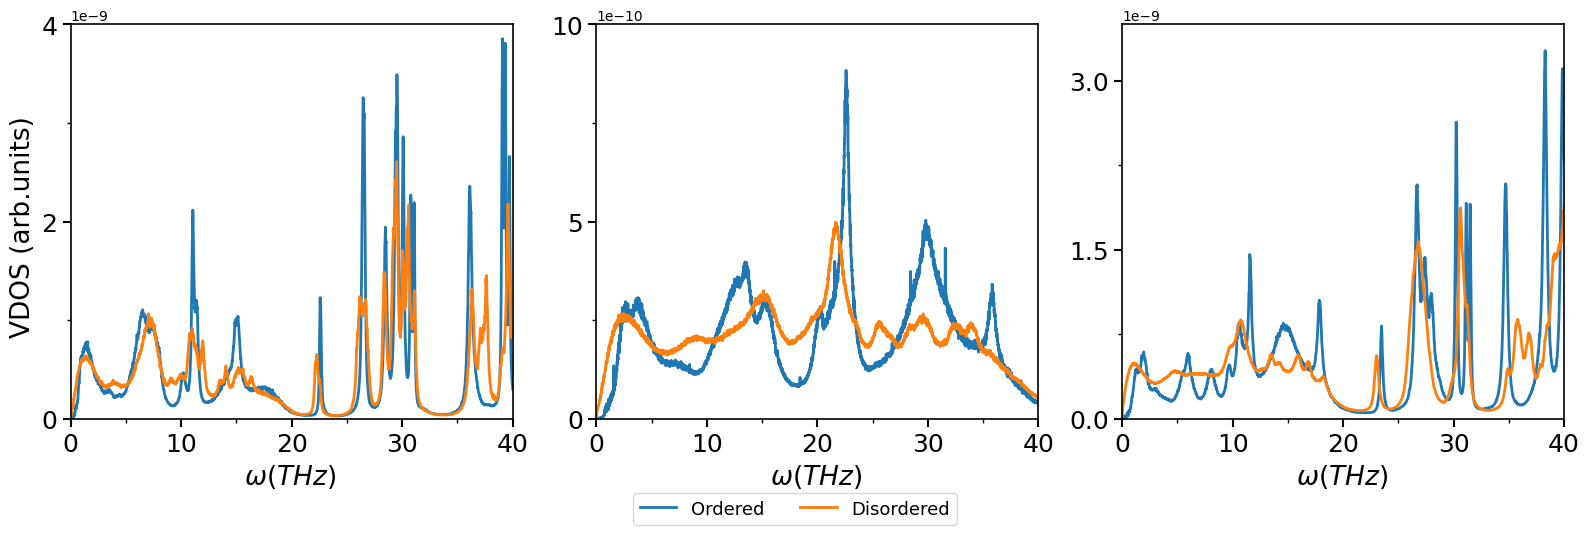

In [189]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pdos_files = {
    'NPG': ("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_NPG_300.dat",
            "/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_NPG_305.dat"),
    'PG':  ("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PG_370.dat",
            "/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PG_375.dat"),
    'PE':  ("/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PE_475.dat",
            "/home/aressanuy/Desktop/doc/NPG/fitxesgrafics/pdos/pdos_PE_480.dat"),
}
# ── Límits de l'eix Y per a cada material ────────────────────────────────────
ylims = {
    'NPG': (0, 4e-9),
    'PG':  (0, 1e-9),
    'PE':  (0, 3.5e-9),
}
# ── Separació dels ticks majors de Y per a cada material ─────────────────────
yticks = {
    'NPG': 2e-9,
    'PG':  5e-10,
    'PE':  1.5e-9,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for idx, (ax, (material, (f_ord, f_dis))) in enumerate(zip(axes, pdos_files.items())):
    freq_ord, pdos_ord = np.loadtxt(f_ord, comments='#', unpack=True)
    freq_dis, pdos_dis = np.loadtxt(f_dis, comments='#', unpack=True)

    l_ord, = ax.plot(freq_ord * 1e-12, pdos_ord, label='Ordered',    linewidth=2)
    l_dis, = ax.plot(freq_dis * 1e-12, pdos_dis, label='Disordered', linewidth=2)

    ax.set_xlim([0, 40])
    ax.set_ylim(ylims[material])
    ax.set_xlabel(r'$\omega(THz)$ ', fontsize=19)
    if idx == 0:
        ax.set_ylabel('VDOS (arb.units) ', fontsize=19)
        legend_handles = [l_ord, l_dis]

    ax.tick_params(axis='both', labelsize=18, width=1.5, length=6)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(yticks[material]))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params(which='minor', length=3, width=1)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

fig.legend(handles=legend_handles, labels=['Ordered', 'Disordered'],
           loc='lower center', ncol=2, fontsize=13, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('pdos_plot.png', dpi=150, bbox_inches='tight')
plt.show()


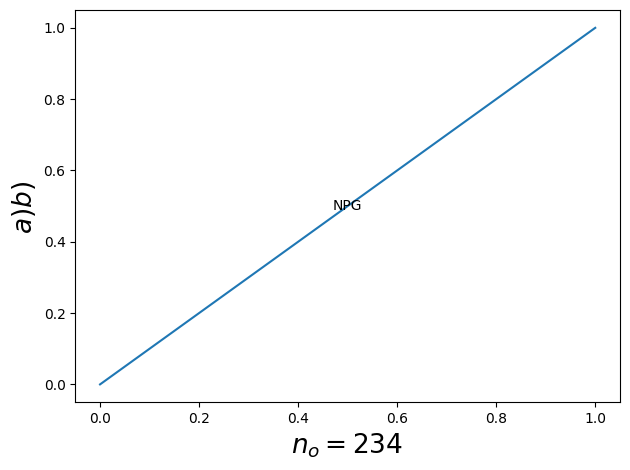

In [299]:

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fig, ax = plt.subplots()

# --- la teva figura aquí ---
ax.plot([0, 1], [0, 1])
ax.set_xlabel(r'$n_o = 2 3 4' \
'$ ', fontsize=19)
ax.set_ylabel(r'$a)b)$ ', fontsize=19)
#ax.xaxis.label.set_color('blue')             # xlabel
#ax.yaxis.label.set_color('blue')  

# Agafa la font que matplotlib està usant per als eixos
axis_font = fm.FontProperties(
    family=plt.rcParams["font.family"],
    size=plt.rcParams["font.size"],      # mateixa mida que els tick labels
    style=plt.rcParams["font.style"],
    weight=plt.rcParams["font.weight"],
)

# Afegeix text amb la mateixa font
ax.text(
    0.5, 0.5,               # coordenades (en unitats de dades, o usa transform=ax.transAxes per fracció)
    "NPG",
    fontproperties=axis_font,
    ha="center", va="center",
    transform=ax.transAxes   # elimina aquesta línia si vols coordenades de dades
)

plt.tight_layout()
plt.savefig("/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/figura_text.pdf", dpi=300)
plt.show()

In [294]:
import numpy as np

x = np.linspace(0, 4*np.pi, 200)
y = np.sin(x)

# Genera path SVG
points = " ".join(f"{xi*50:.2f},{-yi*30+50:.2f}" for xi, yi in zip(x, y))
svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="640" height="100">
  <polyline points="{points}" fill="none" stroke="blue" stroke-width="1.5"/>
</svg>'''

with open("/home/aressanuy/Desktop/doc/paper-npgpgpe/FIGURES/sinus.svg", "w") as f:
    f.write(svg)